In [5]:
import numpy as np
from collections import defaultdict
from copy import deepcopy
from graphviz import Digraph
from typing import Dict

%matplotlib inline

def normalize_dict(counts: Dict) -> Dict:
    total_counts = sum(counts.values())
    if total_counts == 0: return {}
    return {k: v / total_counts for k, v in counts.items()}

In [6]:

# Maximum Likelihood - One Variable

def one_variable_mle(training_data: list[Dict[str, int]]):
    counts = defaultdict(int)
    for data in training_data:
        counts[data["R"]] += 1
    return normalize_dict(counts)

training_data = [{"R": r} for r in [1, 3, 4, 4, 4, 4, 4, 5, 5, 5]]
p_r = one_variable_mle(training_data)
print("P(R):", p_r)


P(R): {1: 0.1, 3: 0.1, 4: 0.5, 5: 0.3}


In [9]:
# Maximum Likelihood - Muti-variables Parameter Sharing

def parameter_sharing_mle(training_data: list[Dict]) -> tuple[Dict, Dict]:
    g_counts = defaultdict(int)
    gr_counts = defaultdict(lambda: defaultdict(int))
    for data in training_data:
        g_counts[data["G"]] += 1
        gr_counts[data["G"]][data["R1"]] += 1
        gr_counts[data["G"]][data["R2"]] += 1

    p_g = normalize_dict(g_counts)    
    p_r_given_g = {g: normalize_dict(r_counts) for g, r_counts in gr_counts.items()}
    return p_g, p_r_given_g


training_data = [
    {"G": "drama", "R1": 4, "R2": 5},
    {"G": "drama", "R1": 4, "R2": 4},
    {"G": "drama", "R1": 5, "R2": 3},
    {"G": "comedy", "R1": 1, "R2": 2},
    {"G": "comedy", "R1": 5, "R2": 4},
]
p_g, p_r_given_g = parameter_sharing_mle(training_data)
print("P(G):", p_g)
print("P(R|G):", p_r_given_g)

P(G): {'drama': 0.6, 'comedy': 0.4}
P(R|G): {'drama': {4: 0.5, 5: 0.3333333333333333, 3: 0.16666666666666666}, 'comedy': {1: 0.25, 2: 0.25, 5: 0.25, 4: 0.25}}


In [14]:
# Laplace Smoothing

# network structure: {variable: (param, [parent1, parent2...])}. param can be shared between different variables
# e.g. {
#     "H1": ("start", []),
#     "E1": ("emit", ["H1"]),
#     "E2": ("emit", ["H2"]),
#     "H2": ("trans", ["H1"]),
# }
# training data: [{variable1: value, variable2: value...}] a list of dict of variable assignments
# e.g. [
#       { "H1": 0, "E1": 0... },
#       { "H1": 0, "E1": 1... },
#      ]
# pseudo counts: { param: {(parent1, parent2): {value, counts}}} dict of initial counts, used for laplace smoothing
# e.g. {
#     "start": {
#         (): {0: lam, 1: lam} 
#     },
#     "trans": {
#         (0,): {0: lam, 1: lam},  
#         (1,): {0: lam, 1: lam}  
#     },
#     "emit": {
#         (0,): {0: lam, 1: lam},  
#         (1,): {0: lam, 1: lam} 
#     }
# }
def fully_observable_learning(network_structure: Dict, training_data: list[Dict], pseudo_counts = None):
    # counts: { 
    #           param: {
    #               (parent1, parent2...): { 
    #                   value: counts
    #               }
    #           } 
    #          }
    if pseudo_counts is None:
        counts = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    else:
        counts = deepcopy(pseudo_counts)

    # count for all conditional distributions
    for data in training_data:
        for var, value in data.items():
            param, parent_vars = network_structure[var]
            parent_values_tuple = tuple(data[parent_var] for parent_var in parent_vars)
            counts[param][parent_values_tuple][value] += 1
    # normalize for all conditional distributions
    # theta : { 
    #           param: {
    #               (parent1, parent2...): { 
    #                   value: probability
    #               }
    #           } 
    #          }
    theta = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
    for param in counts:
        for parents_value in counts[param]:
            theta[param][parents_value] = normalize_dict(counts[param][parents_value])
    return theta

# test laplace smoothing with one variable example: R
def laplace_smoothing_demo(lambda_val: int = 1):
    network_structure = {"R": ("R", [])}
    training_data = [{"R": 1}, {"R": 4}]
    pseudo_counts = {"R": {(): {i: lambda_val for i in range(1, 6)}}}
    theta = fully_observable_learning(network_structure, training_data, pseudo_counts)
    print(f"Smoothing λ={lambda_val}:", dict(theta["R"][()]))

# test different λ
laplace_smoothing_demo(1)
laplace_smoothing_demo(0)
laplace_smoothing_demo(20)

Smoothing λ=1: {1: 0.2857142857142857, 2: 0.14285714285714285, 3: 0.14285714285714285, 4: 0.2857142857142857, 5: 0.14285714285714285}
Smoothing λ=0: {1: 0.5, 2: 0.0, 3: 0.0, 4: 0.5, 5: 0.0}
Smoothing λ=20: {1: 0.20588235294117646, 2: 0.19607843137254902, 3: 0.19607843137254902, 4: 0.20588235294117646, 5: 0.19607843137254902}


In [17]:
# Expectation Maximization with partially observed data
# Example Bayes network: R1 <- G -> R2, G is unobserved variable
def expectation_maximization(training_data: list[Dict], num_iters: int):
    # initial theta parameters
    p_g = {"Drama": 0.5, "Comedy": 0.5}
    p_r_given_g = {
        "Drama": { 1: 0.6, 2: 0.4}, # Break Symmetry
        "Comedy": { 1: 0.4, 2: 0.6} # Conditional distribution need to be different
    }
    for i in range(num_iters):
        # 1. E Step: compute the probability of each g value given this training data, stored as weights
        # For each training data {"R1": r1, "R2": r2}, weights: {"G": g, "R1": r1, "R2": r2} -> P(g | r1, r2) 
        training_data_weights = []
        for data in training_data:
            probs_g = {}
            for g in p_g:
                # P(G, R1, R2) = P(G) * P(R1 | G) * P(R2 | G)
                probs_g[g] = p_g[g] * p_r_given_g[g][data["R1"]] * p_r_given_g[g][data["R2"]]
            # Normalize. P(G | R1, R2) = P(G, R1, R2) / P(R1, R2)
            probs_g = normalize_dict(probs_g)
            for g in probs_g:
                training_data_weights.append(({"G": g, "R1": data["R1"], "R2": data["R2"]}, probs_g[g]))

        # 2. M Step: treat weights as weighted fully observed data, count and normalize. Compute and update theta parameters
        counts_g = defaultdict(float) # {"Drama": count, "Comedy": count}
        counts_gr = defaultdict(lambda: defaultdict(float)) # {"Drama": { 1: count, 2: count}..}
        for values, weight in training_data_weights:
            g, r1, r2 = values["G"], values["R1"], values["R2"]
            counts_g[g] += weight
            counts_gr[g][r1] += weight
            counts_gr[g][r2] += weight
        # Normalize and compute p_g and p_g_given_r
        p_g = normalize_dict(counts_g)
        p_r_given_g = {g: normalize_dict(counts_gr[g]) for g in counts_gr}
        print(f"--- Iteration{i + 1} ---")
        print("P(G):", p_g)
        print("P(R|G):", p_r_given_g)
    return {"p_g": p_g, "p_r_given_g": p_r_given_g}

# Test EM algorithm
unobserved_data = [
    {"R1": 1, "R2": 1},
    {"R1": 1, "R2": 1},
    {"R1": 2, "R2": 2},
    {"R1": 2, "R2": 2},
    {"R1": 1, "R2": 2},
]
theta = expectation_maximization(unobserved_data, num_iters=5)
theta

--- Iteration1 ---
P(G): {'Drama': 0.5, 'Comedy': 0.5}
P(R|G): {'Drama': {1: 0.6538461538461539, 2: 0.3461538461538462}, 'Comedy': {1: 0.3461538461538462, 2: 0.6538461538461539}}
--- Iteration2 ---
P(G): {'Drama': 0.5, 'Comedy': 0.5}
P(R|G): {'Drama': {1: 0.7248648648648649, 2: 0.27513513513513516}, 'Comedy': {1: 0.27513513513513516, 2: 0.7248648648648649}}
--- Iteration3 ---
P(G): {'Drama': 0.5, 'Comedy': 0.5}
P(R|G): {'Drama': {1: 0.7992570097046606, 2: 0.2007429902953394}, 'Comedy': {1: 0.2007429902953394, 2: 0.7992570097046606}}
--- Iteration4 ---
P(G): {'Drama': 0.5, 'Comedy': 0.5}
P(R|G): {'Drama': {1: 0.8525287191886249, 2: 0.14747128081137495}, 'Comedy': {1: 0.14747128081137495, 2: 0.8525287191886249}}
--- Iteration5 ---
P(G): {'Drama': 0.5, 'Comedy': 0.5}
P(R|G): {'Drama': {1: 0.8767575268135566, 2: 0.1232424731864433}, 'Comedy': {1: 0.1232424731864433, 2: 0.8767575268135566}}


{'p_g': {'Drama': 0.5, 'Comedy': 0.5},
 'p_r_given_g': {'Drama': {1: 0.8767575268135566, 2: 0.1232424731864433},
  'Comedy': {1: 0.1232424731864433, 2: 0.8767575268135566}}}

HMM Start Dist: {(): {0: 1.0}}
HMM Trans Dist: {(0,): {1: 0.3333333333333333, 0: 0.6666666666666666}, (1,): {0: 1.0}}
HMM Emit Dist: {(0,): {0: 0.4, 1: 0.6}, (1,): {1: 1.0}}


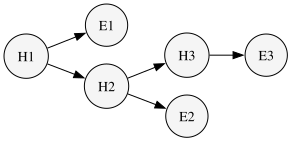

In [ ]:
# Fully observed data - HMM

def visualize_bayesian_network(structure_dict, title="Bayesian Network"):
    dot = Digraph(comment=title)
    dot.attr(rankdir='LR')

    # 收集所有节点与边
    nodes = set(structure_dict.keys())
    edges = []

    for child, (_, parents) in structure_dict.items():
        for parent in parents:
            nodes.add(parent)
            edges.append((parent, child))

    for node in nodes:
        dot.node(node, node, shape='circle', style='filled', fillcolor='whitesmoke')

    for parent, child in edges:
        dot.edge(parent, child)

    return dot

hmm_structure = {
    "H1": ("start", []),
    "H2": ("trans", ["H1"]),
    "H3": ("trans", ["H2"]),
    "E1": ("emit", ["H1"]),
    "E2": ("emit", ["H2"]),
    "E3": ("emit", ["H3"]),
}
hmm_data = [
    {"H1": 0, "E1": 0, "H2": 1, "E2": 1, "H3": 0, "E3": 0},
    {"H1": 0, "E1": 1, "H2": 0, "E2": 1, "H3": 0, "E3": 1},
]
# θ = {p_start, p_trans, p_emit}
hmm_theta = fully_observable_learning(hmm_structure, hmm_data)
print("HMM Start Dist:", dict(hmm_theta["start"]))
print("HMM Trans Dist:", dict(hmm_theta["trans"]))
print("HMM Emit Dist:", dict(hmm_theta["emit"]))

visualize_bayesian_network(hmm_structure, "HMM Structure")